# Bitcoin Market Sentiment vs. Hyperliquid Trader Performance
### Data Science Assignment — Primetrade.ai

**Datasets:**
- Historical Trader Data from Hyperliquid (211,224 records)
- Bitcoin Fear & Greed Index (Alternative.me)

**Objective:** Explore the relationship between trader performance and market sentiment, uncover hidden patterns, and deliver insights that can drive smarter trading strategies.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

BG     = '#0D1117'
FG     = '#E6EDF3'
GRID   = '#21262D'
ACCENT = '#58A6FF'

COLORS = {
    'Extreme Fear' : '#D32F2F',
    'Fear'         : '#FF7043',
    'Neutral'      : '#90A4AE',
    'Greed'        : '#66BB6A',
    'Extreme Greed': '#2E7D32',
}
cat_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
palette   = [COLORS[c] for c in cat_order]

plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': BG,
    'axes.edgecolor'  : GRID, 'axes.labelcolor': FG,
    'xtick.color': FG, 'ytick.color': FG,
    'text.color' : FG, 'grid.color' : GRID,
    'font.family': 'DejaVu Sans', 'font.size': 10,
})

print('Libraries loaded ✅')

Libraries loaded ✅


In [2]:
import os

KAGGLE_BASE = '/kaggle/input'

if os.path.exists(KAGGLE_BASE):
    for root, dirs, files in os.walk(KAGGLE_BASE):
        for f in files:
            print(os.path.join(root, f))
    HIST_PATH = '/kaggle/input/datasets/trishavijayekkumaran/bitcoin-analysis/historical_data.csv'
    FG_PATH   = '/kaggle/input/datasets/trishavijayekkumaran/bitcoin-analysis/fear_greed_index.csv'
else:
    HIST_PATH = 'historical_data.csv'
    FG_PATH   = 'fear_greed_index.csv'

hd = pd.read_csv(HIST_PATH)
fg = pd.read_csv(FG_PATH)

print(f'Historical data : {hd.shape[0]:,} rows × {hd.shape[1]} cols')
print(f'Fear/Greed index: {fg.shape[0]:,} rows × {fg.shape[1]} cols')

/kaggle/input/datasets/trishavijayekkumaran/bitcoin-analysis/historical_data.csv
/kaggle/input/datasets/trishavijayekkumaran/bitcoin-analysis/fear_greed_index.csv
Historical data : 211,224 rows × 16 cols
Fear/Greed index: 2,644 rows × 4 cols


In [3]:
print('=== Historical Data ===')
display(hd.head(3))
print('\n=== Fear & Greed Index ===')
display(fg.head(3))

=== Historical Data ===


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12



=== Fear & Greed Index ===


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03


In [4]:
hd['Timestamp IST'] = pd.to_datetime(hd['Timestamp IST'], dayfirst=True, errors='coerce')
hd['date']          = hd['Timestamp IST'].dt.date.astype(str)
hd['Closed PnL']    = pd.to_numeric(hd['Closed PnL'], errors='coerce').fillna(0)
hd['Fee']           = pd.to_numeric(hd['Fee'],         errors='coerce').fillna(0)
hd['Size USD']      = pd.to_numeric(hd['Size USD'],    errors='coerce').fillna(0)
hd['Net PnL']       = hd['Closed PnL'] - hd['Fee']

closed = hd[hd['Closed PnL'] != 0].copy()

fg['date'] = pd.to_datetime(fg['date']).dt.date.astype(str)

merged = closed.merge(fg[['date', 'value', 'classification']], on='date', how='left')
merged = merged.dropna(subset=['classification'])
merged['classification'] = pd.Categorical(merged['classification'],
                                          categories=cat_order, ordered=True)
merged['win']  = (merged['Closed PnL'] > 0).astype(int)
merged['hour'] = merged['Timestamp IST'].dt.hour
merged['dow']  = merged['Timestamp IST'].dt.day_name()
merged['month']= merged['Timestamp IST'].dt.to_period('M').astype(str)

print(f'Closing trades after merge: {len(merged):,}')
print(f'Date range: {merged["Timestamp IST"].min().date()} → {merged["Timestamp IST"].max().date()}')
print(f'Null FG values: {merged["classification"].isna().sum()}')
display(merged['classification'].value_counts())

Closing trades after merge: 104,402
Date range: 2023-12-14 → 2025-05-01
Null FG values: 0


classification
Fear             29808
Greed            25176
Extreme Greed    20853
Neutral          18159
Extreme Fear     10406
Name: count, dtype: int64

In [5]:
print('=== Overall Statistics ===')
print(f"Total Realised PnL : ${merged['Closed PnL'].sum():>15,.2f}")
print(f"Overall Win Rate   : {merged['win'].mean()*100:>15.1f}%")
print(f"Unique Traders     : {merged['Account'].nunique():>15,}")
print(f"Unique Coins       : {merged['Coin'].nunique():>15,}")
print(f"Largest Single Gain: ${merged['Closed PnL'].max():>15,.2f}")
print(f"Largest Single Loss: ${merged['Closed PnL'].min():>15,.2f}")
print()
display(merged[['Closed PnL', 'Fee', 'Size USD']].describe().round(2))

=== Overall Statistics ===
Total Realised PnL : $  10,254,486.95
Overall Win Rate   :            83.2%
Unique Traders     :              32
Unique Coins       :             220
Largest Single Gain: $     135,329.09
Largest Single Loss: $    -117,990.10



,Closed PnL,Fee,Size USD
count,104402.00,104402.00,104402.00
mean,98.22,1.20,5673.95
std,1303.85,7.25,39586.12
min,-117990.10,-1.02,0.01
25%,0.41,0.02,178.86
50%,6.05,0.11,594.17
75%,38.19,0.45,2024.90
max,135329.09,837.47,3921430.72


In [6]:
by_sent = merged.groupby('classification', observed=True).agg(
    total_pnl   = ('Closed PnL', 'sum'),
    avg_pnl     = ('Closed PnL', 'mean'),
    median_pnl  = ('Closed PnL', 'median'),
    win_rate    = ('win', 'mean'),
    trade_count = ('Closed PnL', 'count'),
    total_vol   = ('Size USD', 'sum'),
).reset_index()
by_sent['win_rate_pct'] = by_sent['win_rate'] * 100

display(by_sent[['classification','total_pnl','avg_pnl','win_rate_pct','trade_count']].round(2))

,classification,total_pnl,avg_pnl,win_rate_pct,trade_count
0,Extreme Fear,739110.25,71.03,76.22,10406
1,Fear,3357155.44,112.63,87.29,29808
2,Neutral,1292920.68,71.20,82.39,18159
3,Greed,2150129.27,85.40,76.89,25176
4,Extreme Greed,2715171.31,130.21,89.17,20853


In [7]:
daily_by_sent = merged.groupby(['date','classification'], observed=True)['Closed PnL'].sum().reset_index()
sharpe_by_sent = (
    daily_by_sent
    .groupby('classification', observed=True)
    .apply(lambda g: g['Closed PnL'].mean() / (g['Closed PnL'].std() + 1e-9))
    .reset_index(name='sharpe')
    .sort_values('sharpe', ascending=False)
)
print('=== Sharpe-like Ratio by Sentiment ===')
display(sharpe_by_sent)

=== Sharpe-like Ratio by Sentiment ===


,classification,sharpe
2,Neutral,0.576342
0,Extreme Fear,0.521354
1,Fear,0.426888
4,Extreme Greed,0.336928
3,Greed,0.192246


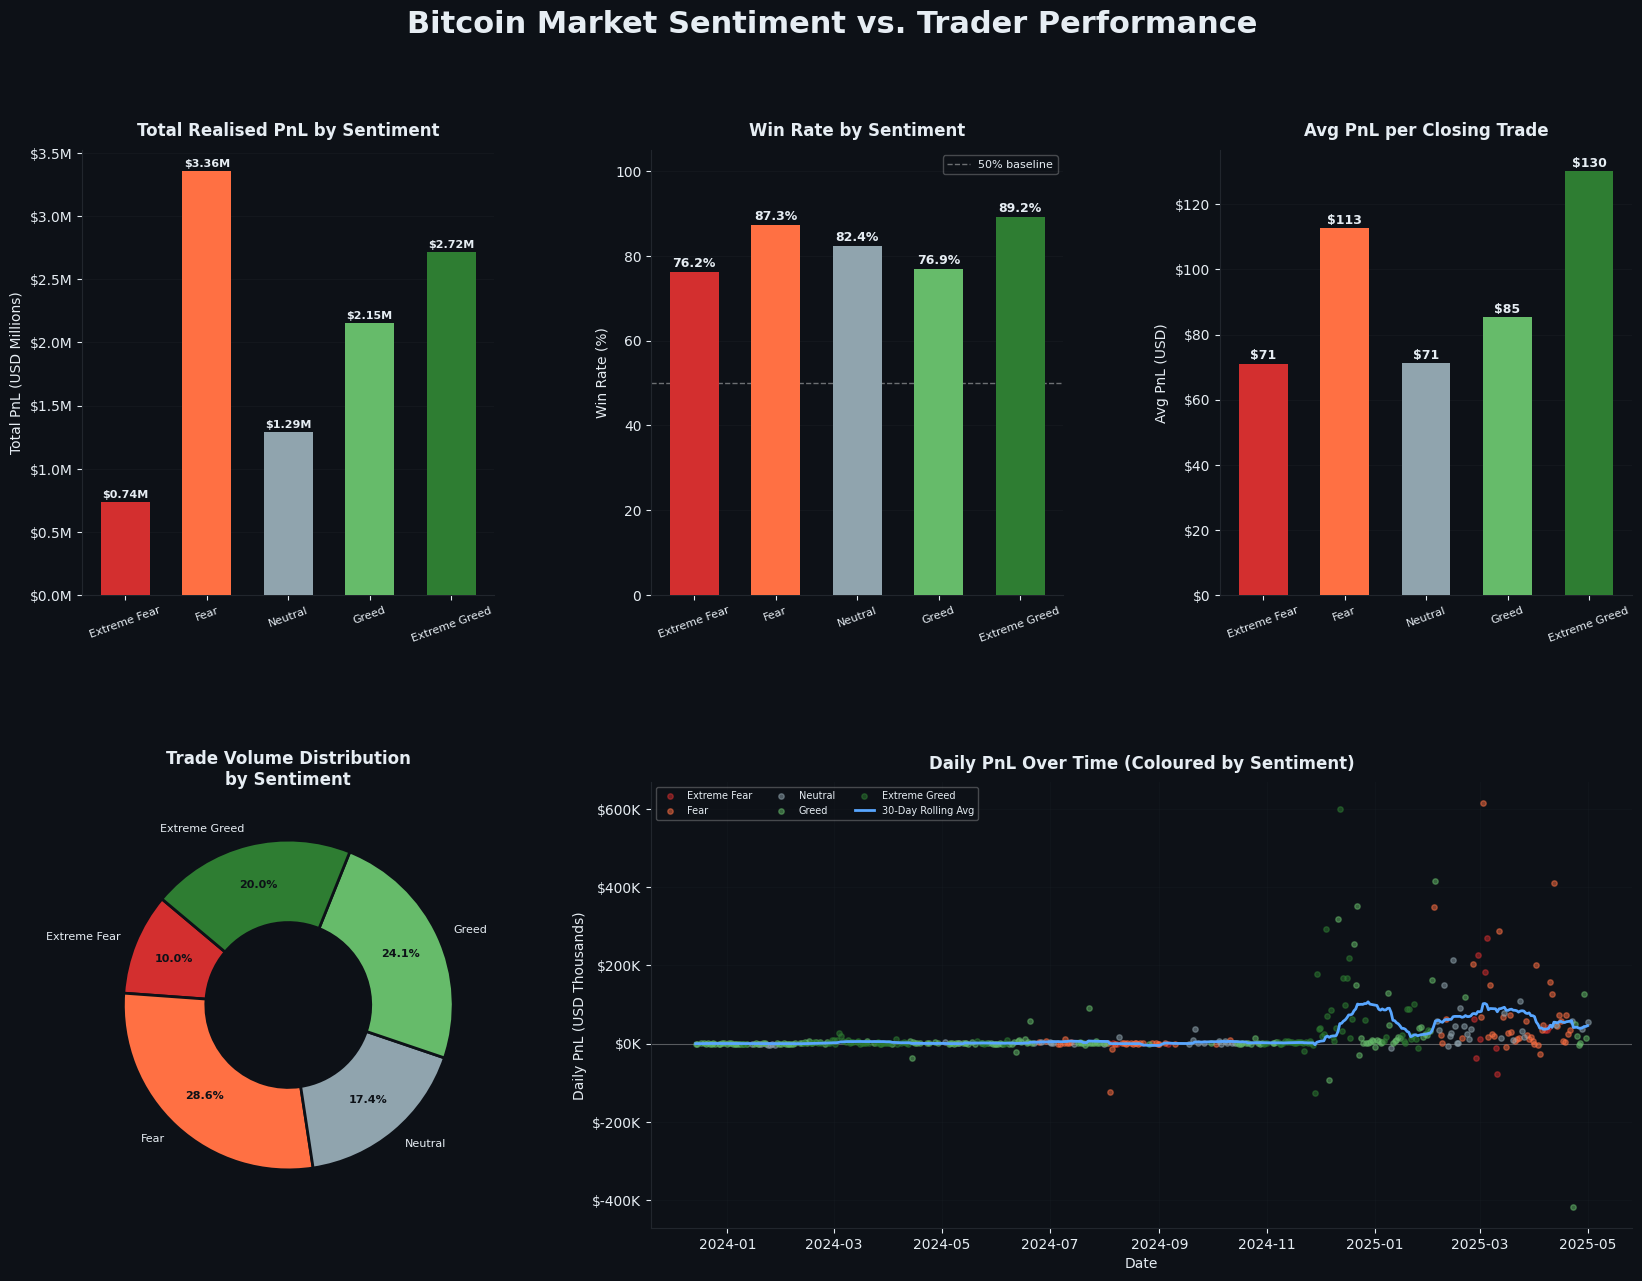

Figure 1 saved.


In [8]:
daily = merged.groupby('date').agg(
    daily_pnl      = ('Closed PnL', 'sum'),
    fg_value       = ('value', 'first'),
    classification = ('classification', 'first')
).reset_index()
daily['date'] = pd.to_datetime(daily['date'])
daily = daily.sort_values('date')

fig = plt.figure(figsize=(20, 14), facecolor=BG)
fig.suptitle('Bitcoin Market Sentiment vs. Trader Performance',
             fontsize=22, fontweight='bold', color=FG, y=0.98)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.38)

ax1 = fig.add_subplot(gs[0, 0])
bars = ax1.bar(cat_order, by_sent['total_pnl']/1e6, color=palette, width=0.6, zorder=3)
ax1.set_title('Total Realised PnL by Sentiment', fontsize=12, fontweight='bold', color=FG, pad=10)
ax1.set_ylabel('Total PnL (USD Millions)'); ax1.tick_params(axis='x', labelrotation=20, labelsize=8)
ax1.grid(axis='y', alpha=0.3, zorder=0)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x:.1f}M'))
for bar, val in zip(bars, by_sent['total_pnl']):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
             f'${val/1e6:.2f}M', ha='center', va='bottom', fontsize=8, color=FG, fontweight='bold')
ax1.spines[['top','right']].set_visible(False)

ax2 = fig.add_subplot(gs[0, 1])
bars2 = ax2.bar(cat_order, by_sent['win_rate_pct'], color=palette, width=0.6, zorder=3)
ax2.axhline(50, color='white', linestyle='--', alpha=0.4, linewidth=1, label='50% baseline')
ax2.set_title('Win Rate by Sentiment', fontsize=12, fontweight='bold', color=FG, pad=10)
ax2.set_ylabel('Win Rate (%)'); ax2.set_ylim(0, 105); ax2.tick_params(axis='x', labelrotation=20, labelsize=8)
ax2.grid(axis='y', alpha=0.3, zorder=0)
for bar, val in zip(bars2, by_sent['win_rate_pct']):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=9, color=FG, fontweight='bold')
ax2.legend(fontsize=8, framealpha=0.3)
ax2.spines[['top','right']].set_visible(False)

ax3 = fig.add_subplot(gs[0, 2])
bars3 = ax3.bar(cat_order, by_sent['avg_pnl'], color=palette, width=0.6, zorder=3)
ax3.set_title('Avg PnL per Closing Trade', fontsize=12, fontweight='bold', color=FG, pad=10)
ax3.set_ylabel('Avg PnL (USD)'); ax3.tick_params(axis='x', labelrotation=20, labelsize=8)
ax3.grid(axis='y', alpha=0.3, zorder=0)
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x:.0f}'))
for bar, val in zip(bars3, by_sent['avg_pnl']):
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f'${val:.0f}', ha='center', va='bottom', fontsize=9, color=FG, fontweight='bold')
ax3.spines[['top','right']].set_visible(False)

ax4 = fig.add_subplot(gs[1, 0])
wedges, texts, autotexts = ax4.pie(
    by_sent['trade_count'], labels=cat_order, colors=palette,
    autopct='%1.1f%%', startangle=140, pctdistance=0.75,
    wedgeprops=dict(width=0.5, edgecolor=BG, linewidth=2))
for t in texts: t.set_color(FG); t.set_fontsize(8)
for at in autotexts: at.set_color(BG); at.set_fontsize(8); at.set_fontweight('bold')
ax4.set_title('Trade Volume Distribution\nby Sentiment', fontsize=12, fontweight='bold', color=FG, pad=10)

ax5 = fig.add_subplot(gs[1, 1:])
rolling_pnl = daily.set_index('date')['daily_pnl'].rolling('30D').mean()
for sent in cat_order:
    sub = daily[daily['classification']==sent]
    ax5.scatter(sub['date'], sub['daily_pnl']/1000,
                color=COLORS[sent], alpha=0.5, s=15, zorder=3, label=sent)
ax5.plot(rolling_pnl.index, rolling_pnl.values/1000,
         color=ACCENT, linewidth=2, zorder=5, label='30-Day Rolling Avg')
ax5.axhline(0, color='white', alpha=0.3, linewidth=0.8)
ax5.set_title('Daily PnL Over Time (Coloured by Sentiment)', fontsize=12, fontweight='bold', color=FG, pad=10)
ax5.set_ylabel('Daily PnL (USD Thousands)'); ax5.set_xlabel('Date')
ax5.grid(alpha=0.2, zorder=0)
ax5.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x:.0f}K'))
ax5.legend(loc='upper left', fontsize=7, framealpha=0.3, ncol=3)
ax5.spines[['top','right']].set_visible(False)

plt.savefig('fig1_sentiment_overview.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Figure 1 saved.')

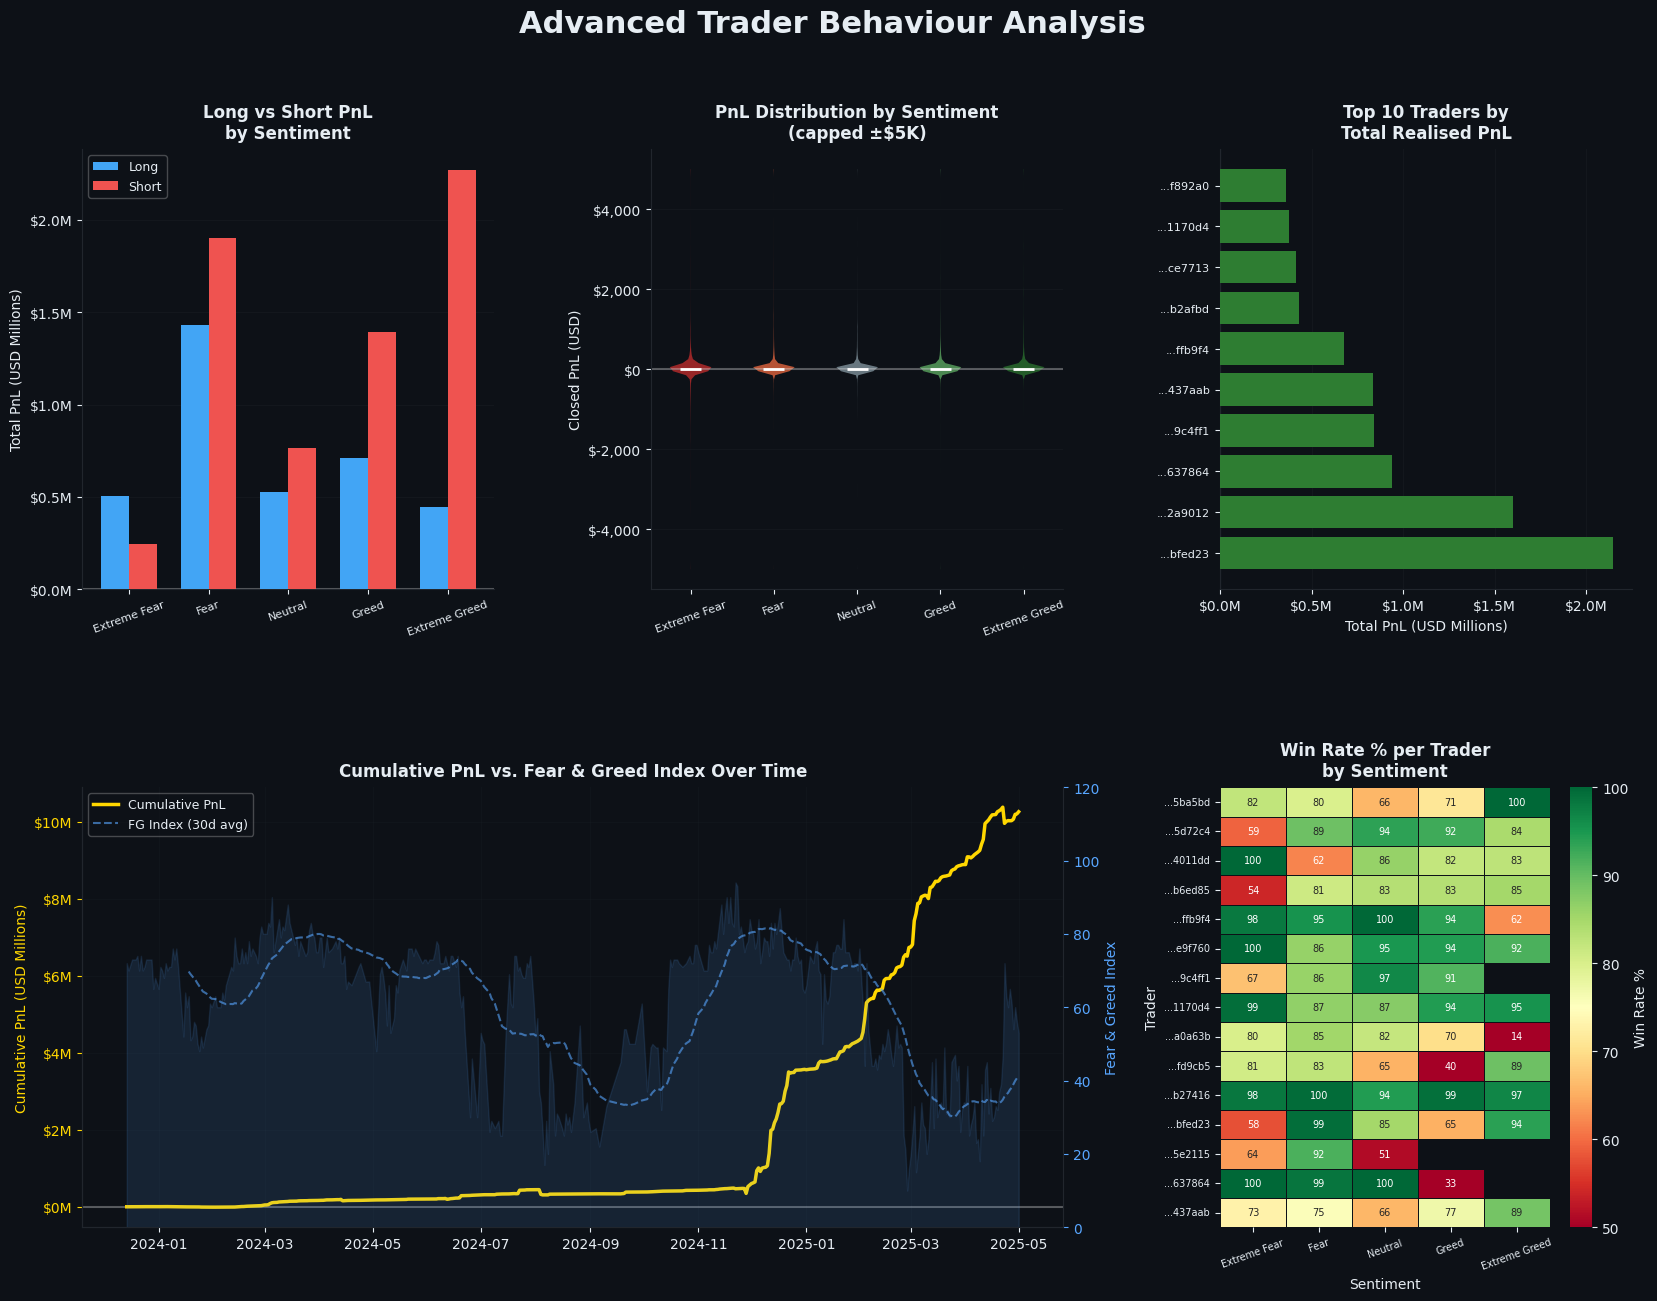

Figure 2 saved.


In [9]:
dir_map = {
    'Close Long':'Long','Close Short':'Short',
    'Open Long':'Long','Open Short':'Short',
    'Buy':'Long','Sell':'Short'
}
merged['direction_clean'] = merged['Direction'].map(dir_map)
dir_sent = (
    merged.groupby(['classification','direction_clean'], observed=True)
    .agg(pnl=('Closed PnL','sum'), trades=('Closed PnL','count'))
    .reset_index().dropna(subset=['direction_clean'])
)

fig = plt.figure(figsize=(20, 14), facecolor=BG)
fig.suptitle('Advanced Trader Behaviour Analysis',
             fontsize=22, fontweight='bold', color=FG, y=0.98)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

ax1 = fig.add_subplot(gs[0, 0])
dir_sent2  = dir_sent[dir_sent['direction_clean'].isin(['Long','Short'])]
dir_pivot  = dir_sent2.pivot_table(index='classification', columns='direction_clean',
                                    values='pnl', observed=True).reindex(cat_order)
x = np.arange(len(cat_order)); w = 0.35
ax1.bar(x - w/2, dir_pivot.get('Long',  pd.Series([0]*5)).values/1e6, w, label='Long',  color='#42A5F5', zorder=3)
ax1.bar(x + w/2, dir_pivot.get('Short', pd.Series([0]*5)).values/1e6, w, label='Short', color='#EF5350', zorder=3)
ax1.set_xticks(x); ax1.set_xticklabels(cat_order, rotation=20, fontsize=8)
ax1.set_title('Long vs Short PnL\nby Sentiment', fontsize=12, fontweight='bold', color=FG, pad=8)
ax1.set_ylabel('Total PnL (USD Millions)')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x:.1f}M'))
ax1.grid(axis='y', alpha=0.3, zorder=0); ax1.legend(fontsize=9, framealpha=0.3)
ax1.axhline(0, color='white', alpha=0.3); ax1.spines[['top','right']].set_visible(False)

ax2 = fig.add_subplot(gs[0, 1])
capped = merged.copy()
capped['Closed PnL'] = capped['Closed PnL'].clip(-5000, 5000)
vp = ax2.violinplot(
    [capped[capped['classification']==c]['Closed PnL'].values for c in cat_order],
    positions=range(len(cat_order)), showmedians=True, showextrema=False)
for pc, col in zip(vp['bodies'], palette):
    pc.set_facecolor(col); pc.set_alpha(0.7)
vp['cmedians'].set_color('white'); vp['cmedians'].set_linewidth(2)
ax2.set_xticks(range(len(cat_order))); ax2.set_xticklabels(cat_order, rotation=20, fontsize=8)
ax2.axhline(0, color='white', alpha=0.3)
ax2.set_title('PnL Distribution by Sentiment\n(capped ±$5K)', fontsize=12, fontweight='bold', color=FG, pad=8)
ax2.set_ylabel('Closed PnL (USD)')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax2.grid(axis='y', alpha=0.3); ax2.spines[['top','right']].set_visible(False)

ax3 = fig.add_subplot(gs[0, 2])
top_accounts = merged.groupby('Account')['Closed PnL'].sum().nlargest(10)
short_labels = [f'...{a[-6:]}' for a in top_accounts.index]
colors_acc   = ['#2E7D32' if v>0 else '#D32F2F' for v in top_accounts.values]
ax3.barh(range(len(top_accounts)), top_accounts.values/1e6, color=colors_acc, zorder=3)
ax3.set_yticks(range(len(top_accounts))); ax3.set_yticklabels(short_labels, fontsize=8)
ax3.set_title('Top 10 Traders by\nTotal Realised PnL', fontsize=12, fontweight='bold', color=FG, pad=8)
ax3.set_xlabel('Total PnL (USD Millions)')
ax3.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x:.1f}M'))
ax3.grid(axis='x', alpha=0.3, zorder=0); ax3.axvline(0, color='white', alpha=0.3)
ax3.spines[['top','right']].set_visible(False)

ax4 = fig.add_subplot(gs[1, 0:2])
daily2 = daily.sort_values('date').copy()
daily2['cum_pnl'] = daily2['daily_pnl'].cumsum()
ax4b = ax4.twinx()
ax4b.fill_between(daily2['date'], daily2['fg_value'], alpha=0.12, color=ACCENT)
ax4b.plot(daily2['date'], daily2['fg_value'].rolling(30).mean(),
          color=ACCENT, linewidth=1.5, linestyle='--', alpha=0.6, label='FG Index (30d avg)')
ax4b.set_ylabel('Fear & Greed Index', color=ACCENT)
ax4b.tick_params(axis='y', colors=ACCENT); ax4b.set_ylim(0, 120)
ax4b.spines[['top']].set_visible(False)
ax4.plot(daily2['date'], daily2['cum_pnl']/1e6, color='#FFD700', linewidth=2.5, zorder=5, label='Cumulative PnL')
ax4.axhline(0, color='white', alpha=0.3)
ax4.set_title('Cumulative PnL vs. Fear & Greed Index Over Time', fontsize=12, fontweight='bold', color=FG, pad=8)
ax4.set_ylabel('Cumulative PnL (USD Millions)', color='#FFD700')
ax4.tick_params(axis='y', colors='#FFD700')
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x:.0f}M'))
ax4.grid(alpha=0.2, zorder=0); ax4.spines[['top','right']].set_visible(False)
lines1, labels1 = ax4.get_legend_handles_labels()
lines2, labels2 = ax4b.get_legend_handles_labels()
ax4.legend(lines1+lines2, labels1+labels2, loc='upper left', fontsize=9, framealpha=0.3)

ax5 = fig.add_subplot(gs[1, 2])
acc_sent = merged.groupby(['Account','classification'], observed=True)['win'].mean().unstack(fill_value=np.nan)
acc_sent = acc_sent.reindex(columns=cat_order)
acc_sent.index = [f'...{a[-6:]}' for a in acc_sent.index]
top_accs_idx = merged.groupby('Account')['win'].count().nlargest(15).index
short_top    = [f'...{a[-6:]}' for a in top_accs_idx]
acc_top      = acc_sent.loc[acc_sent.index.isin(short_top)]
sns.heatmap(acc_top*100, ax=ax5, cmap='RdYlGn', vmin=50, vmax=100,
            annot=True, fmt='.0f', linewidths=0.5, linecolor=BG,
            cbar_kws={'label':'Win Rate %'}, annot_kws={'size':7})
ax5.set_title('Win Rate % per Trader\nby Sentiment', fontsize=12, fontweight='bold', color=FG, pad=8)
ax5.set_xlabel('Sentiment'); ax5.set_ylabel('Trader')
ax5.tick_params(axis='x', rotation=20, labelsize=7)
ax5.tick_params(axis='y', labelsize=7)

plt.savefig('fig2_advanced_analysis.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Figure 2 saved.')

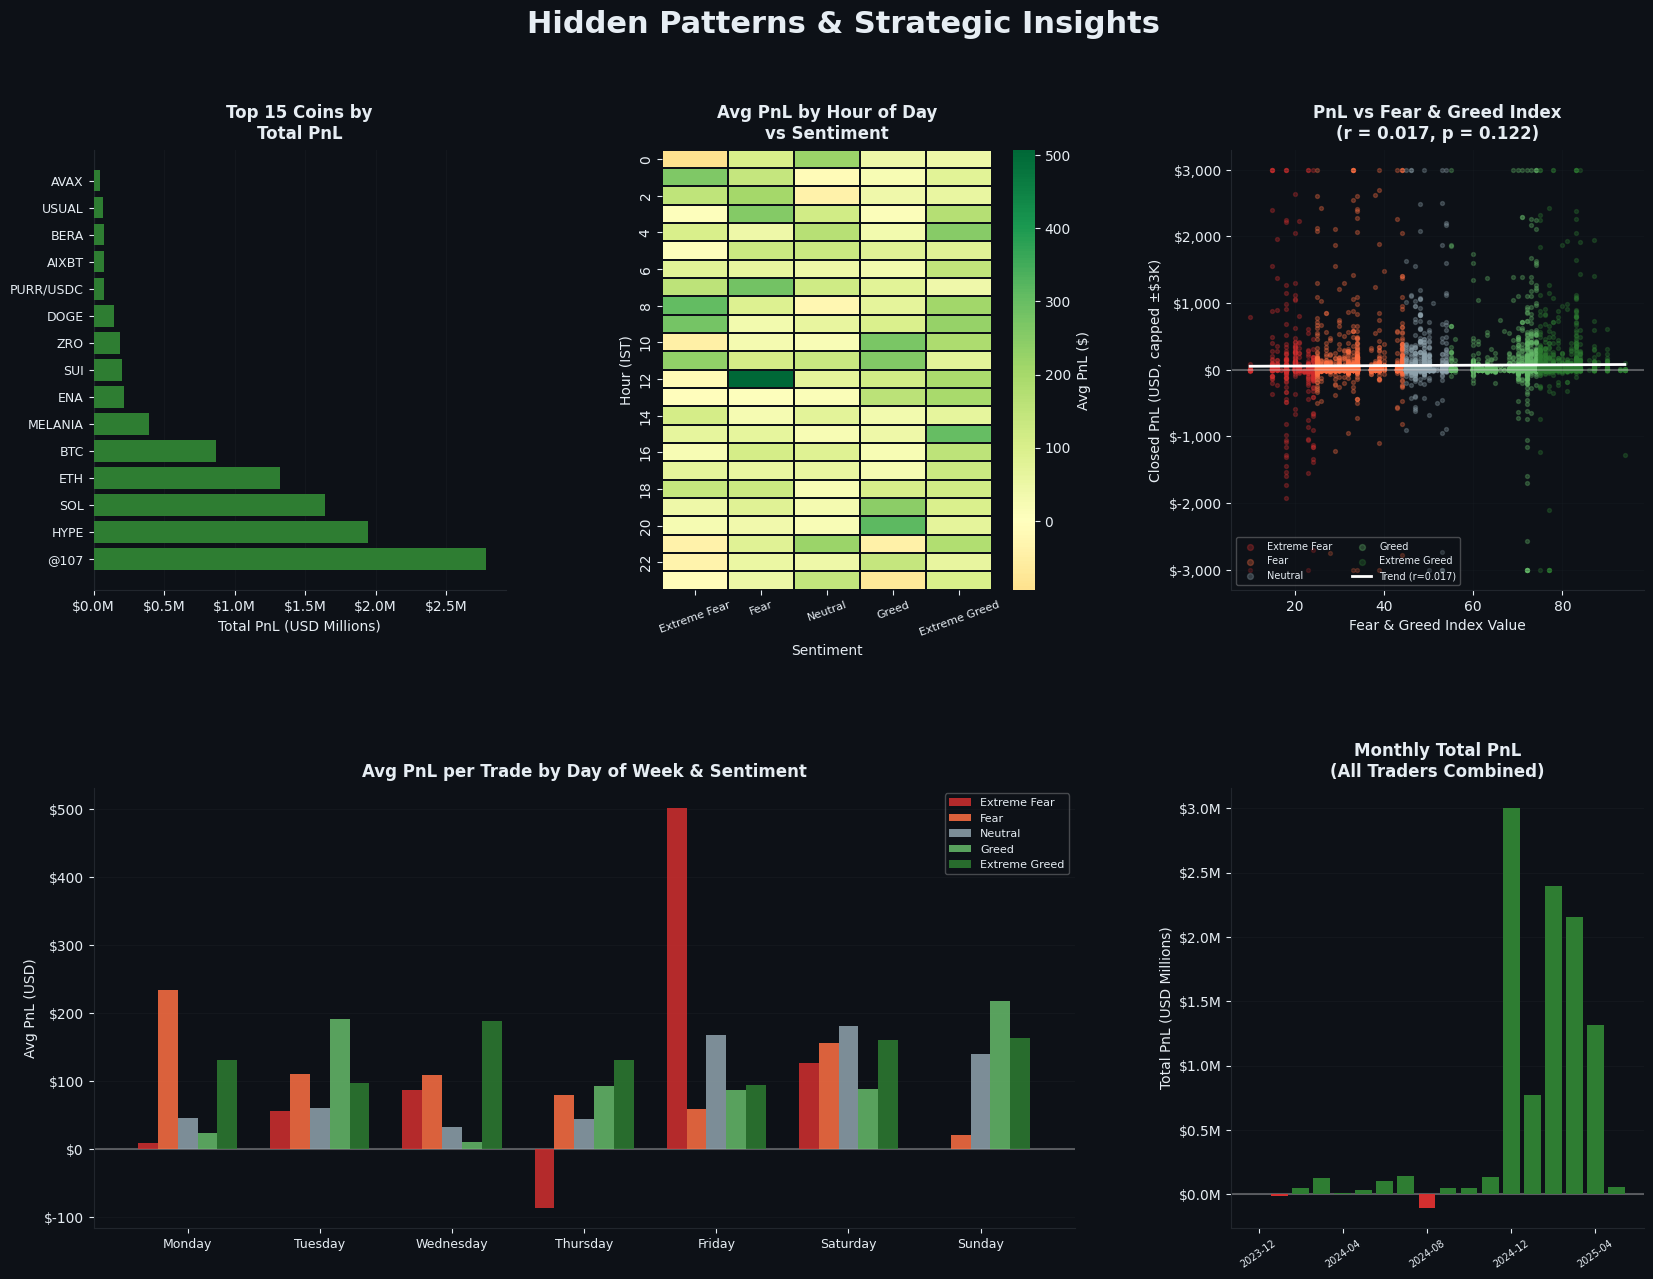

Figure 3 saved.


In [10]:
fig = plt.figure(figsize=(20, 14), facecolor=BG)
fig.suptitle('Hidden Patterns & Strategic Insights',
             fontsize=22, fontweight='bold', color=FG, y=0.98)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

ax1 = fig.add_subplot(gs[0, 0])
coin_pnl   = merged.groupby('Coin')['Closed PnL'].sum().nlargest(15)
colors_c   = ['#2E7D32' if v>0 else '#D32F2F' for v in coin_pnl.values]
ax1.barh(range(len(coin_pnl)), coin_pnl.values/1e6, color=colors_c, zorder=3)
ax1.set_yticks(range(len(coin_pnl))); ax1.set_yticklabels(coin_pnl.index, fontsize=9)
ax1.set_title('Top 15 Coins by\nTotal PnL', fontsize=12, fontweight='bold', color=FG, pad=8)
ax1.set_xlabel('Total PnL (USD Millions)')
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x:.1f}M'))
ax1.grid(axis='x', alpha=0.3, zorder=0); ax1.axvline(0, color='white', alpha=0.3)
ax1.spines[['top','right']].set_visible(False)

ax2 = fig.add_subplot(gs[0, 1])
hour_sent = merged.groupby(['hour','classification'], observed=True)['Closed PnL'].mean().unstack(fill_value=0)
hour_sent = hour_sent.reindex(columns=cat_order)
sns.heatmap(hour_sent, ax=ax2, cmap='RdYlGn', center=0,
            annot=False, linewidths=0.3, linecolor=BG,
            cbar_kws={'label':'Avg PnL ($)'}, yticklabels=2)
ax2.set_title('Avg PnL by Hour of Day\nvs Sentiment', fontsize=12, fontweight='bold', color=FG, pad=8)
ax2.set_xlabel('Sentiment'); ax2.set_ylabel('Hour (IST)')
ax2.tick_params(axis='x', rotation=20, labelsize=8)

ax3 = fig.add_subplot(gs[0, 2])
sample = merged.sample(min(8000, len(merged)), random_state=42)
for sent in cat_order:
    sub = sample[sample['classification']==sent]
    ax3.scatter(sub['value'], sub['Closed PnL'].clip(-3000, 3000),
                color=COLORS[sent], alpha=0.3, s=8, label=sent)
slope, intercept, r, p, _ = stats.linregress(sample['value'], sample['Closed PnL'].clip(-3000,3000))
xr = np.linspace(sample['value'].min(), sample['value'].max(), 100)
ax3.plot(xr, slope*xr+intercept, color='white', linewidth=2, zorder=5, label=f'Trend (r={r:.3f})')
ax3.axhline(0, color='white', alpha=0.3)
ax3.set_title(f'PnL vs Fear & Greed Index\n(r = {r:.3f}, p = {p:.3f})', fontsize=12, fontweight='bold', color=FG, pad=8)
ax3.set_xlabel('Fear & Greed Index Value'); ax3.set_ylabel('Closed PnL (USD, capped ±$3K)')
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax3.legend(fontsize=7, framealpha=0.3, markerscale=1.5, ncol=2)
ax3.grid(alpha=0.2); ax3.spines[['top','right']].set_visible(False)

ax4 = fig.add_subplot(gs[1, 0:2])
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_sent  = merged.groupby(['dow','classification'], observed=True)['Closed PnL'].mean().unstack(fill_value=0)
dow_sent  = dow_sent.reindex(index=dow_order, columns=cat_order)
x = np.arange(len(dow_order)); w = 0.15
for i, (sent, col) in enumerate(COLORS.items()):
    ax4.bar(x + i*w - 2*w, dow_sent.get(sent, 0).values, w, label=sent, color=col, zorder=3, alpha=0.85)
ax4.set_xticks(x); ax4.set_xticklabels(dow_order, fontsize=9)
ax4.set_title('Avg PnL per Trade by Day of Week & Sentiment', fontsize=12, fontweight='bold', color=FG, pad=8)
ax4.set_ylabel('Avg PnL (USD)')
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax4.grid(axis='y', alpha=0.3, zorder=0); ax4.axhline(0, color='white', alpha=0.3)
ax4.legend(fontsize=8, framealpha=0.3, loc='upper right')
ax4.spines[['top','right']].set_visible(False)

ax5 = fig.add_subplot(gs[1, 2])
monthly   = merged.groupby('month')['Closed PnL'].sum().reset_index()
monthly['month_dt'] = pd.to_datetime(monthly['month'])
monthly   = monthly.sort_values('month_dt')
colors_m  = ['#2E7D32' if v>0 else '#D32F2F' for v in monthly['Closed PnL']]
ax5.bar(range(len(monthly)), monthly['Closed PnL']/1e6, color=colors_m, zorder=3, width=0.8)
ax5.set_xticks(range(0, len(monthly), 4))
ax5.set_xticklabels(monthly['month'].iloc[::4], rotation=35, fontsize=7)
ax5.set_title('Monthly Total PnL\n(All Traders Combined)', fontsize=12, fontweight='bold', color=FG, pad=8)
ax5.set_ylabel('Total PnL (USD Millions)')
ax5.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x:.1f}M'))
ax5.grid(axis='y', alpha=0.3, zorder=0); ax5.axhline(0, color='white', alpha=0.3)
ax5.spines[['top','right']].set_visible(False)

plt.savefig('fig3_patterns.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Figure 3 saved.')

In [11]:
corr, pval = stats.pearsonr(daily['fg_value'], daily['daily_pnl'])
print(f'Pearson r = {corr:.4f}')
print(f'p-value   = {pval:.4f}  ({"significant" if pval < 0.05 else "not significant"} at 5% level)')
print(f'Interpretation: {"Weak NEGATIVE" if corr < 0 else "Weak POSITIVE"} — traders do slightly '
      f'better on {"fearful" if corr < 0 else "greedy"} days')

print()

groups = [merged[merged['classification']==c]['Closed PnL'].clip(-10000,10000).values for c in cat_order]
f_stat, p_anova = stats.f_oneway(*groups)
print(f'One-Way ANOVA across sentiment groups:')
print(f'  F-statistic = {f_stat:.4f}')
print(f'  p-value     = {p_anova:.6f}  ({"significant" if p_anova < 0.05 else "not significant"} at 5% level)')

Pearson r = -0.0984
p-value   = 0.0442  (significant at 5% level)
Interpretation: Weak NEGATIVE — traders do slightly better on fearful days

One-Way ANOVA across sentiment groups:
  F-statistic = 22.5037
  p-value     = 0.000000  (significant at 5% level)


In [12]:
best_coin = (
    merged.groupby(['classification','Coin'], observed=True)['Closed PnL']
    .sum().reset_index()
    .sort_values('Closed PnL', ascending=False)
    .groupby('classification', observed=True).first().reset_index()
)
best_coin['Closed PnL'] = best_coin['Closed PnL'].map('${:,.0f}'.format)
print('Best performing coin per sentiment regime:')
display(best_coin[['classification','Coin','Closed PnL']])

Best performing coin per sentiment regime:


,classification,Coin,Closed PnL
0,Extreme Fear,HYPE,"$482,084"
1,Fear,HYPE,"$840,306"
2,Neutral,SOL,"$303,376"
3,Greed,@107,"$724,342"
4,Extreme Greed,@107,"$1,988,619"


In [13]:
summary = by_sent[['classification','total_pnl','avg_pnl','win_rate_pct','trade_count']].copy()
summary.columns = ['Sentiment','Total PnL','Avg PnL/Trade','Win Rate (%)','# Trades']
summary['Total PnL']     = summary['Total PnL'].map('${:,.0f}'.format)
summary['Avg PnL/Trade'] = summary['Avg PnL/Trade'].map('${:.2f}'.format)
summary['Win Rate (%)']  = summary['Win Rate (%)'].map('{:.1f}%'.format)
summary['# Trades']      = summary['# Trades'].map('{:,}'.format)

print('=== Final Summary: Trader Performance by Market Sentiment ===')
display(summary)

print('\n=== Sharpe-like Ratio by Sentiment ===')
display(sharpe_by_sent.sort_values('sharpe', ascending=False))

print(f'\n=== Overall KPIs ===')
print(f"Total Realised PnL  : ${merged['Closed PnL'].sum():>14,.2f}")
print(f"Overall Win Rate    : {merged['win'].mean()*100:>14.1f}%")
print(f"Total Unique Traders: {merged['Account'].nunique():>14,}")
print(f"Total Unique Coins  : {merged['Coin'].nunique():>14,}")

=== Final Summary: Trader Performance by Market Sentiment ===


,Sentiment,Total PnL,Avg PnL/Trade,Win Rate (%),# Trades
0,Extreme Fear,"$739,110",$71.03,76.2%,"10,406"
1,Fear,"$3,357,155",$112.63,87.3%,"29,808"
2,Neutral,"$1,292,921",$71.20,82.4%,"18,159"
3,Greed,"$2,150,129",$85.40,76.9%,"25,176"
4,Extreme Greed,"$2,715,171",$130.21,89.2%,"20,853"



=== Sharpe-like Ratio by Sentiment ===


,classification,sharpe
2,Neutral,0.576342
0,Extreme Fear,0.521354
1,Fear,0.426888
4,Extreme Greed,0.336928
3,Greed,0.192246



=== Overall KPIs ===
Total Realised PnL  : $ 10,254,486.95
Overall Win Rate    :           83.2%
Total Unique Traders:             32
Total Unique Coins  :            220
